# Climate Visibility Intelligence Dashboard

## Notebook 01 - Dataset Understanding

### Objective
Understand the weather dataset before preprocessing and model building.

**Target Variable:** Visibility (km)

**Author:** Tanmoy Das

In [1]:
import pandas as pd
df=pd.read_csv("../data/raw/weatherHistory.csv")

In [2]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
df.shape

(96453, 12)

In [4]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 8.8 MB


In [6]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [7]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [8]:
df.describe(include="object")

C:\Users\tanmo\AppData\Local\Temp\ipykernel_18988\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Formatted Date,Summary,Precip Type,Daily Summary
count,96453,96453,95936,96453
unique,96429,27,2,214
top,2010-08-02 00:00:00.000 +0200,Partly Cloudy,rain,Mostly cloudy throughout the day.
freq,2,31733,85224,20085


In [9]:
df["Loud Cover"].value_counts()

Loud Cover
0.0    96453
Name: count, dtype: int64

In [10]:
(df["Pressure (millibars)"]==0).sum()

np.int64(1288)

1,288 rows have a pressure of 0 millibars.

That's about 1.34% of the dataset.

In [11]:
df["Pressure (millibars)"].describe()

count    96453.000000
mean      1003.235956
std        116.969906
min          0.000000
25%       1011.900000
50%       1016.450000
75%       1021.090000
max       1046.380000
Name: Pressure (millibars), dtype: float64

In [12]:
df["Pressure (millibars)"].value_counts().head(10)

Pressure (millibars)
0.0       1288
1017.7     123
1015.0     119
1015.8     118
1018.0     118
1016.7     117
1019.1     117
1016.9     115
1017.3     114
1015.9     114
Name: count, dtype: int64

In [13]:
df[df["Pressure (millibars)"] == 0].head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
858,2006-08-14 18:00:00.000 +0200,Partly Cloudy,rain,22.477778,22.477778,0.58,10.8192,159.0,11.1251,0.0,0.0,Mostly cloudy until night.
874,2006-08-15 10:00:00.000 +0200,Partly Cloudy,rain,21.061111,21.061111,0.73,7.7924,264.0,11.2056,0.0,0.0,Partly cloudy until evening.
924,2006-08-17 12:00:00.000 +0200,Clear,rain,28.838889,29.611111,0.51,9.6600,177.0,9.9820,0.0,0.0,Partly cloudy until morning.
945,2006-08-18 09:00:00.000 +0200,Clear,rain,24.950000,24.950000,0.69,16.0195,180.0,9.9015,0.0,0.0,Partly cloudy starting overnight continuing un...
1074,2006-08-22 18:00:00.000 +0200,Partly Cloudy,rain,23.811111,23.811111,0.45,16.0195,290.0,11.2056,0.0,0.0,Partly cloudy starting in the morning.


In [14]:
df[df["Pressure (millibars)"] == 0].shape

(1288, 12)

# Dataset Understanding - Key Findings

## Dataset Overview
- Total Rows: 96,453
- Total Columns: 12
- Target Variable: Visibility (km)

## Missing Values
- Precip Type has 517 missing values.
- All other columns have no missing values.

## Data Types
- Numerical Columns: 8
- Categorical Columns: 4

## Important Observations
- Loud Cover contains only one value (0.0) and is likely not useful for prediction.
- Pressure (millibars) contains 1,288 invalid values equal to 0.
- Formatted Date should be converted to datetime in preprocessing.
- Summary and Daily Summary are categorical/text features that require preprocessing.

In [19]:
numerical_columns=df.select_dtypes(include=["number"]).columns
categorical_columns=df.select_dtypes(include=["str"]).columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


Numerical Columns:
['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)']

Categorical Columns:
['Formatted Date', 'Summary', 'Precip Type', 'Daily Summary']


In [17]:
df.duplicated().sum()

np.int64(24)

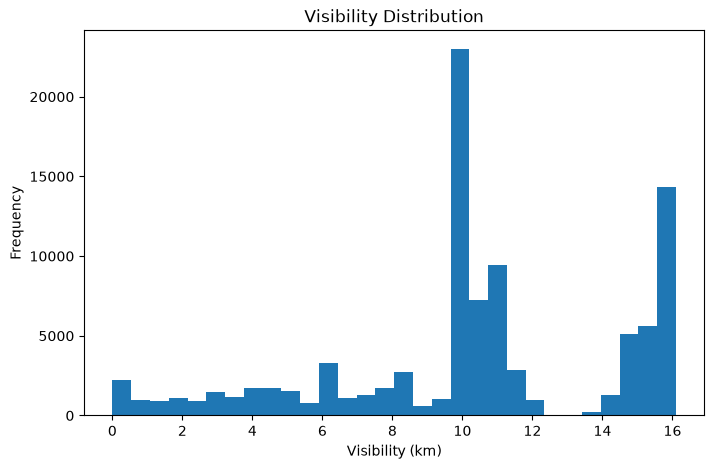

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Visibility (km)"], bins=30)

plt.title("Visibility Distribution")
plt.xlabel("Visibility (km)")
plt.ylabel("Frequency")

plt.show()

In [20]:
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].nunique())


Formatted Date
96429

Summary
27

Precip Type
2

Daily Summary
214


In [21]:
df.corr(numeric_only=True)

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
Temperature (C),1.000000,0.992629,-0.632255,0.008957,0.029988,0.392847,NaN,-0.005447
Apparent Temperature (C),0.992629,1.000000,-0.602571,-0.056650,0.029031,0.381718,NaN,-0.000219
Humidity,-0.632255,-0.602571,1.000000,-0.224951,0.000735,-0.369173,NaN,0.005454
Wind Speed (km/h),0.008957,-0.056650,-0.224951,1.000000,0.103822,0.100749,NaN,-0.049263
Wind Bearing (degrees),0.029988,0.029031,0.000735,0.103822,1.000000,0.047594,NaN,-0.011651
Visibility (km),0.392847,0.381718,-0.369173,0.100749,0.047594,1.000000,NaN,0.059818
Loud Cover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pressure (millibars),-0.005447,-0.000219,0.005454,-0.049263,-0.011651,0.059818,NaN,1.000000


# Final Conclusion

## Dataset Summary
- Total Records: 96,453
- Total Features: 12
- Target Variable: Visibility (km)

## Key Findings
- The dataset contains both numerical and categorical features.
- Only the "Precip Type" column has missing values.
- "Loud Cover" has no variation and will be removed during preprocessing.
- "Pressure (millibars)" contains invalid zero values that require treatment.
- "Formatted Date" should be converted to datetime.
- Temperature and Apparent Temperature are highly correlated.
- Humidity has a moderate negative relationship with Visibility.